In [ ]:
%load_ext autoreload 
%autoreload 2

import os, sys
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../../.."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(os.path.join(os.getcwd(), ".."))

import math
import numpy as np
import pandas as pd
from numpy import array
from numpy import array, arange, abs as np_abs
from numpy.fft import rfft, rfftfreq
from math import sin, pi
from scipy import signal
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import random

import importlib
import model as md
import view as vw
from tqdm import tqdm

importlib.reload(md)
importlib.reload(vw)

from model.relevant_methods import phase_methods

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
c:\Users\Артем\Desktop\Вуз\Аспирантура\Диссертация\Алгоритм\Relaxation_frequency_phase_algorithm\notebooks\Complex_ms\Big_statistics\Monte_carlo\..


<module 'view' from 'c:\\Users\\Артем\\Desktop\\Вуз\\Аспирантура\\Диссертация\\Алгоритм\\Relaxation_frequency_phase_algorithm\\view\\__init__.py'>

In [ ]:
def monte_carlo_phase(phase_method,num_iter=1000):
    results = []

    for i in tqdm(range(num_iter), desc=f"Метод {phase_method.__name__}", unit=" шага"):

        F=400e3
        gen_unstable=1

        # --- Случайные параметры ---
        T=1/F
        fs_mult = random.randrange(3, 100, 1)
        fs = F * fs_mult

        duration_T=random.randrange(3, 100, 1)
        duration = duration_T * T
        
        phase_real=random.randrange(1, 180, 1)
        bits=random.randrange(5, 35, 1)

        # --- Генерация сигналов ---
        t = np.linspace(0, duration, int(duration * fs))

        phase = md.generate_common_phase(
            t,
            F,
            gen_unstable,
            phase0_deg=0
        )

        U, I = md.generate_signals_from_phase(
            phase,
            phase_diff_deg=phase_real
        )

        #U = md.add_SNR(U, SNR)
        #I = md.add_SNR(I, SNR)

        U = md.adc_quantize(U, int(bits), 1)
        I = md.adc_quantize(I, int(bits), 1)
        
        phase_estimated = phase_method(t, U, I, F)
        err_deg = abs(abs(phase_real) - abs(phase_estimated))

        # --- Сохраняем результаты ---
        results.append({
            "FSM": fs_mult,
            "DT": duration_T,
            "phase_real": phase_real,
            "phase_error_deg": err_deg
        })

    return pd.DataFrame(results)

In [ ]:
Y=[]
for i in range(0,len(phase_methods),1):
    Y.append(monte_carlo_phase(phase_methods[i], 20000))


Метод get_phase_SWFR: 100%|██████████| 20000/20000 [00:13<00:00, 1462.69 шага/s]


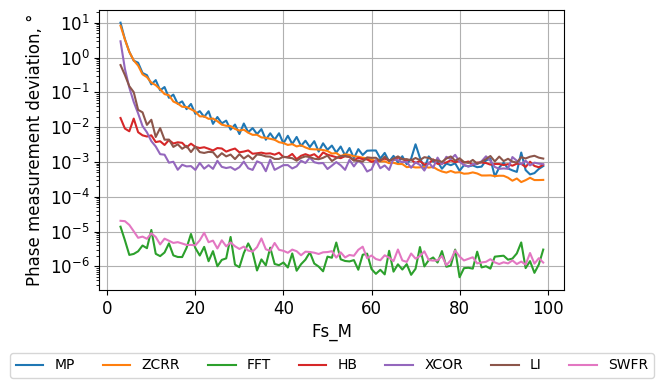

In [ ]:
def clean_name(func):
    return func.__name__.replace("get_phase_", "").replace("get_phase", "")

param="fs_mult"#	fs_mult	duration	phase_real	phase_error_deg SNR

method_names = [clean_name(m) for m in phase_methods]

fig = plt.figure(figsize=(6, 8))
gs = fig.add_gridspec(2, 1)
front = 12
ax1 = fig.add_subplot(gs[0, 0])

median_errors=[]
for i in range(len(Y)):
    median_error = Y[i].groupby(param)["phase_error_deg"].median() 
    ax1.plot(median_error.index,median_error, label=method_names[i])


ax1.set_xlabel("Fs_M", fontsize=front)
ax1.set_ylabel('Phase measurement deviation, °', fontsize=front)
ax1.tick_params(axis='both', labelsize=front)
ax1.grid(True)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=len(method_names))
ax1.set_yscale('log')

In [113]:
from scipy.optimize import curve_fit

median_error=Y[0].groupby("fs_mult")["phase_error_deg"].median()

def falling_exp(x, a, b, c):
    """y = a * exp(-b * x) + c"""
    return a * np.exp(-b * x) + c

data_x=median_error.index
data_y=median_error.values

# 3. Аппроксимация (curve_fit)
# p0 - начальное предположение для коэффициентов [a, b, c]
popt, pcov = curve_fit(falling_exp, data_x, data_y, p0=[1, 0.1, 0], sigma=data_y)

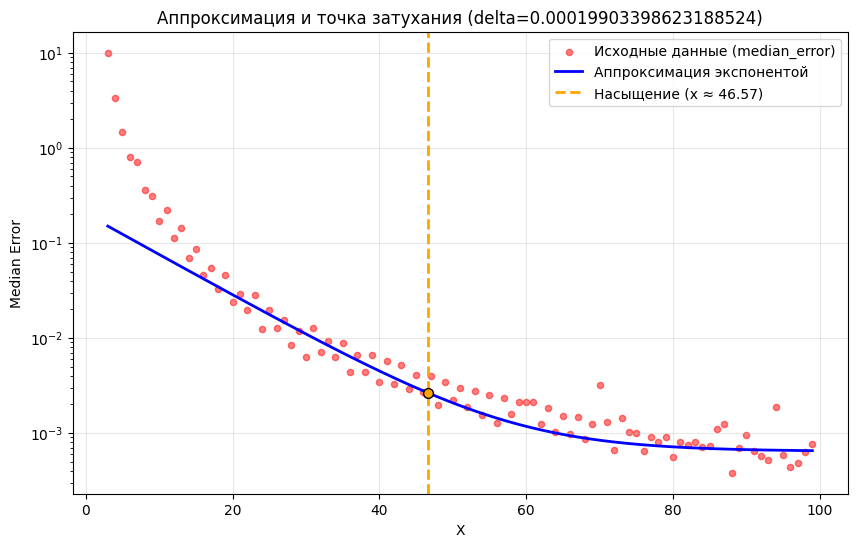

Точка, где скорость падения меньше 0.00019903398623188524: x = 46.57


In [114]:
import matplotlib.pyplot as plt

# 1. Создаем плотную сетку X для плавной кривой
x_model = np.linspace(data_x.min(), data_x.max(), 500)

# 2. Вычисляем Y на основе найденных коэффициентов popt
# Оператор * распаковывает список параметров [a, b, c] в функцию
y_model = falling_exp(x_model, *popt)

# 3. Визуализация
# 1. Расчет точки насыщения (до построения графика)
a, b, c = popt

initial_slope = abs(a * b) 

# Устанавливаем порог как 1% (0.01) от начальной крутизны
delta = initial_slope * 0.01 

x_stop = -np.log(delta / (abs(a) * b)) / b

# 2. Построение единого графика
plt.figure(figsize=(10, 6))

# Точки данных
plt.scatter(data_x, data_y, color='red', label='Исходные данные (median_error)', s=20, alpha=0.5)

# Аппроксимирующая кривая
plt.plot(x_model, y_model, color='blue', linewidth=2, label='Аппроксимация экспонентой')

# Вертикальная линия в точке насыщения
plt.axvline(x=x_stop, color='orange', linestyle='--', linewidth=2, 
            label=f'Насыщение (x ≈ {x_stop:.2f})')

# Дополнительно: точка пересечения на самой кривой
y_stop = falling_exp(x_stop, *popt)
plt.scatter(x_stop, y_stop, color='orange', s=50, edgecolors='black', zorder=5)

# Оформление
plt.xlabel('X')
plt.ylabel('Median Error')
plt.title(f'Аппроксимация и точка затухания (delta={delta})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.show()

print(f"Точка, где скорость падения меньше {delta}: x = {x_stop:.2f}")


In [143]:
def plot_all_params(Y, params, method_names):
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(len(params), 1, figsize=(7, 10), sharey=False)
    front = 12

    for j, param in enumerate(params):
        ax = axes[j]

        for i in range(len(Y)):
            median_error = Y[i].groupby(param)["phase_error_deg"].median()
            ax.plot(median_error.index, median_error, label=method_names[i])

        ax.set_xlabel(param, fontsize=front)
        ax.set_ylabel('Error, °', fontsize=front)
        ax.set_yscale('log')
        ax.grid(True)
        ax.tick_params(axis='both', labelsize=front)

    # одна общая легенда
    fig.legend(method_names, loc='upper center', ncol=len(method_names))

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

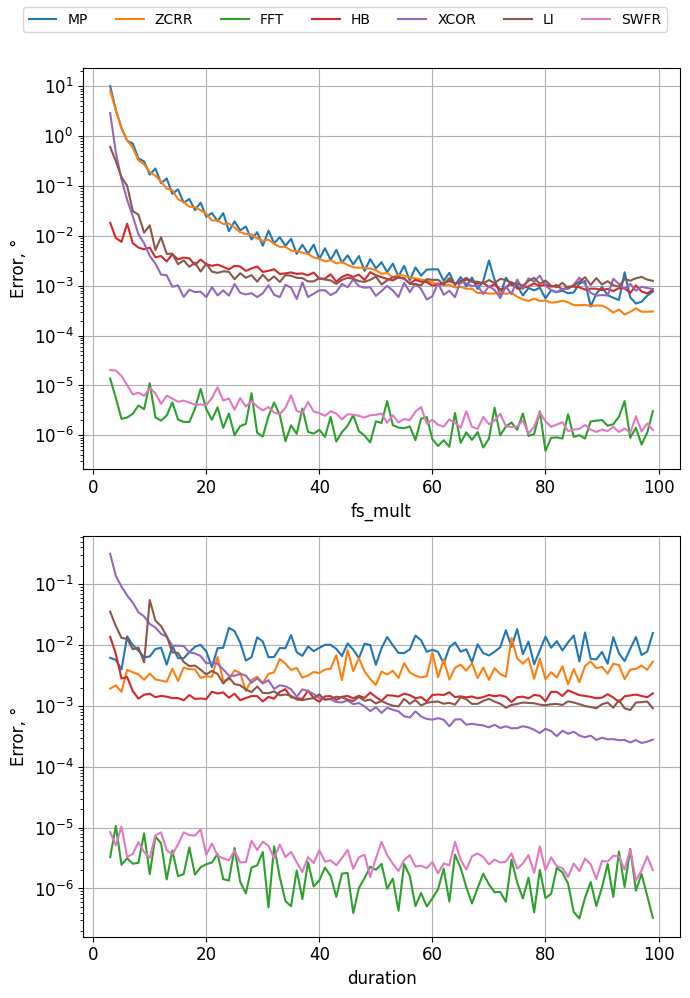

In [144]:
params = ["fs_mult", "duration"]
method_names = [clean_name(m) for m in phase_methods]

plot_all_params(Y, params, method_names)

In [139]:
import numpy as np
from scipy.optimize import curve_fit


def falling_exp(x, a, b, c):
    return a * np.exp(-b * x) + c


def get_saturation_with_r2(x, y, r2_threshold=0.9):
    # 🔧 приведение типов
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # защита от мусора
    if len(x) < 3:
        return None, 0.0

    try:
        popt, _ = curve_fit(
            falling_exp,
            x,
            y,
            p0=[np.max(y), 0.1, np.min(y)],
            maxfev=10000
        )
    except:
        return None, 0.0

    y_fit = falling_exp(x, *popt)

    # R²
    ss_res = np.sum((y - y_fit) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)

    if ss_tot == 0:
        return None, 0.0

    r2 = 1 - ss_res / ss_tot

    if r2 < r2_threshold:
        return None, r2

    # saturation
    a, b, c = popt

    # защита от странных фиттов
    if b <= 0:
        return None, r2

    initial_slope = abs(a * b)
    delta = initial_slope * 0.01

    x_stop = -np.log(delta / (abs(a) * b)) / b

    return x_stop, r2

import pandas as pd

def build_table_r2(Y, params, method_names, r2_threshold=0.9):
    data = {}

    for param in params:
        values = []

        for i, df in enumerate(Y):
            median_error = df.groupby(param)["phase_error_deg"].median()

            x = median_error.index.values
            y = median_error.values

            x_stop, r2 = get_saturation_with_r2(x, y, r2_threshold)

            if x_stop is None:
                values.append(np.nan)
                print(f"{method_names[i]} | {param}: плохой фит (R²={r2:.3f})")
            else:
                values.append(round(float(x_stop), 2))
                print(f"{method_names[i]} | {param}: OK (R²={r2:.3f})")

        data[param] = values

    return pd.DataFrame(data, index=method_names)

In [142]:
params = ["fs_mult", "duration"]
method_names = [clean_name(m) for m in phase_methods]

df_sat = build_table_r2(Y, params, method_names,0.5)

print("\nТаблица точек насыщения:")
print(df_sat)

MP | fs_mult: OK (R²=0.994)
ZCRR | fs_mult: OK (R²=0.996)
FFT | fs_mult: плохой фит (R²=0.317)
HB | fs_mult: OK (R²=0.829)
XCOR | fs_mult: OK (R²=0.999)
LI | fs_mult: OK (R²=0.998)
SWFR | fs_mult: OK (R²=0.825)
MP | duration: плохой фит (R²=0.032)
ZCRR | duration: плохой фит (R²=0.095)
FFT | duration: плохой фит (R²=0.342)
HB | duration: OK (R²=0.982)
XCOR | duration: OK (R²=0.974)
LI | duration: OK (R²=0.547)
SWFR | duration: плохой фит (R²=0.418)

Таблица точек насыщения:
      fs_mult  duration
MP       4.60       NaN
ZCRR     5.42       NaN
FFT       NaN       NaN
HB      28.95      5.40
XCOR     2.58      8.14
LI       6.91     49.32
SWFR    27.35       NaN
